In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [94]:
df = pd.read_csv('Mall_Customers.csv')

In [95]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [97]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [98]:
df = df.drop('CustomerID', axis=1)

In [99]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [100]:
obj = pd.get_dummies(df['Gender'], drop_first=True)

In [101]:
X = pd.concat([obj, df.drop('Gender', axis=1)], axis=1)

In [102]:
X.head()

,Male,Age,Annual Income (k$),Spending Score (1-100)
0,True,19,15,39
1,True,21,15,81
2,False,20,16,6
3,False,23,16,77
4,False,31,17,40


In [103]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

In [104]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [105]:
inertia = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

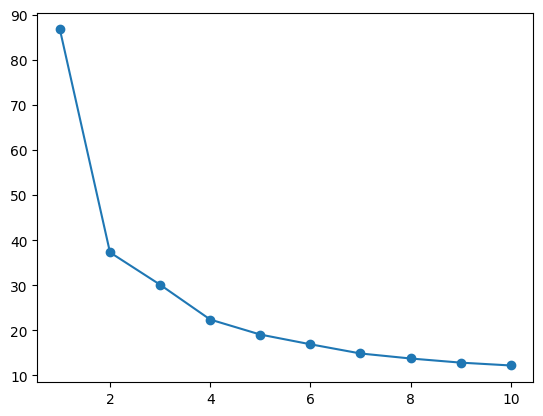

In [106]:
plt.plot(range(1,11), inertia, marker='o');

In [107]:
from kneed import KneeLocator

In [108]:
kl = KneeLocator(range(1,11), inertia, curve='convex', direction='decreasing')

In [109]:
kl.elbow

np.int64(2)

In [110]:
model_kmeans = KMeans(n_clusters=2, random_state=42)

In [111]:
model_kmeans.fit(X_scaled)

KMeans(n_clusters=2, random_state=42)

In [112]:
labels = model_kmeans.predict(X_scaled)

In [113]:
silhouette_score(X_scaled, labels)

np.float64(0.5194624832665107)

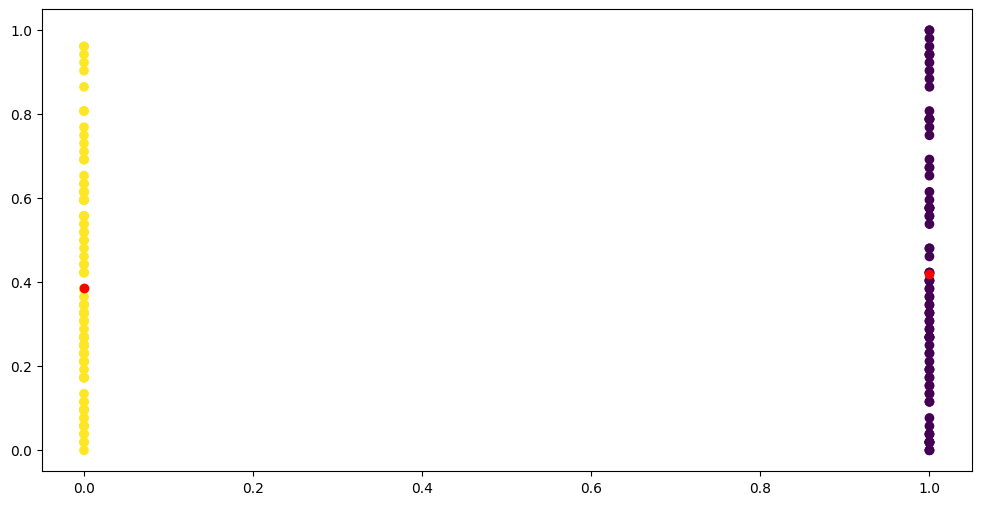

In [114]:
plt.figure(figsize=(12,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(model_kmeans.cluster_centers_[:, 0], model_kmeans.cluster_centers_[:, 1], c='red');

In [118]:
from sklearn.decomposition import PCA

In [119]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

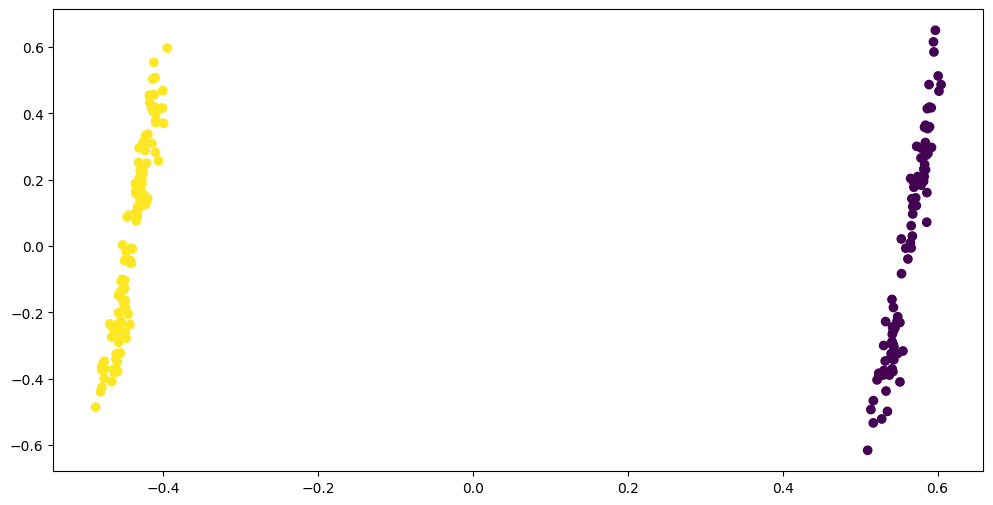

In [121]:
plt.figure(figsize=(12,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels);